# Logistic regression


In [1]:
from sklearn.datasets import make_classification
import numpy as np


In [26]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

In [27]:
import matplotlib.pyplot as plt


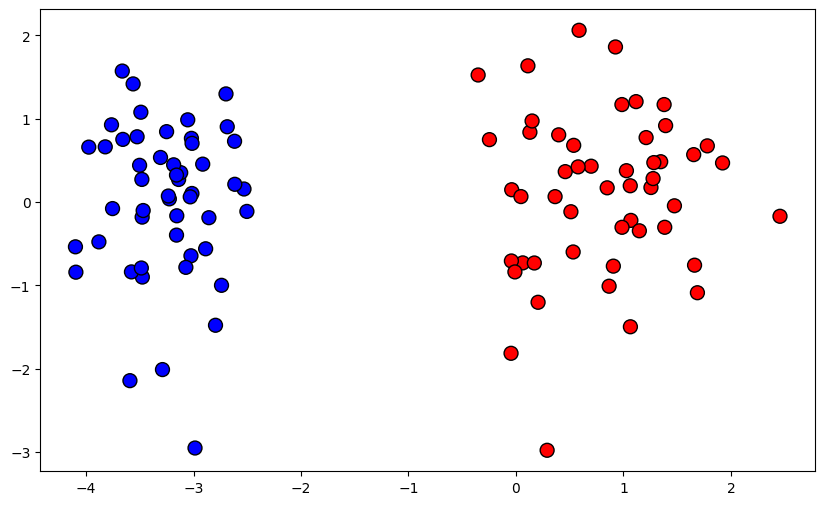

In [28]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='bwr',s=100,edgecolor='k')

In [29]:
step=lambda x:1 if x>=0 else 0

In [30]:
def perceptron(X,y):
    X=np.insert(X,0,1,axis=1)
    w=np.ones(X.shape[1])
    for i in range(1000):
        j=np.random.randint(0,X.shape[0])
        y_pred=step(np.dot(w,X[j]))
        w=w+(y[j]-y_pred)*X[j]
    return w[0],w[1:]

In [31]:
intercept,coef=perceptron(X,y)

In [32]:
print("intercept:",intercept)
print("coef:",coef)

intercept: 4.0
coef: [4.46823234 0.23261687]


In [33]:
m=-coef[0]/coef[1]
c=-intercept/coef[1]

In [34]:
x_input=np.linspace(-3,3,100)
y_input=m*x_input+c

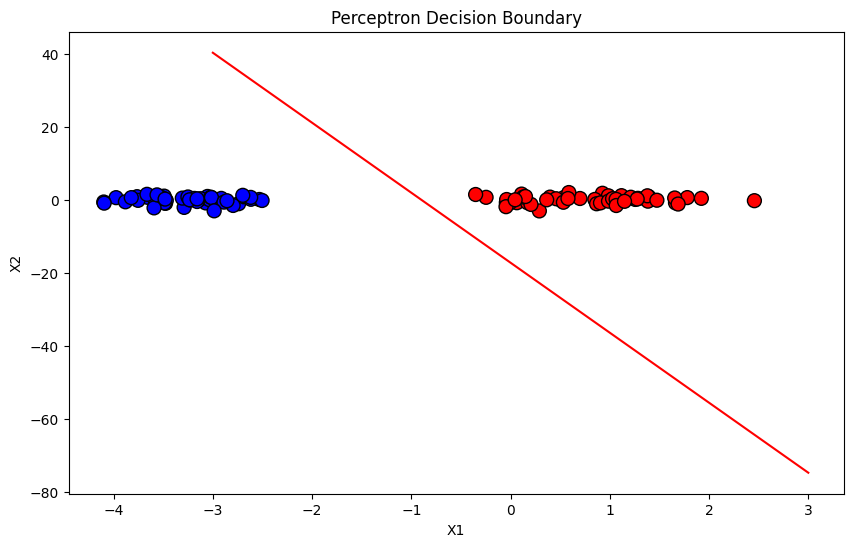

In [35]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='bwr',s=100,edgecolor='k')
plt.plot(x_input,y_input,color='red')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Perceptron Decision Boundary')
plt.show()

# Logistic regression using sigmoid function

In [36]:
X,y=make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

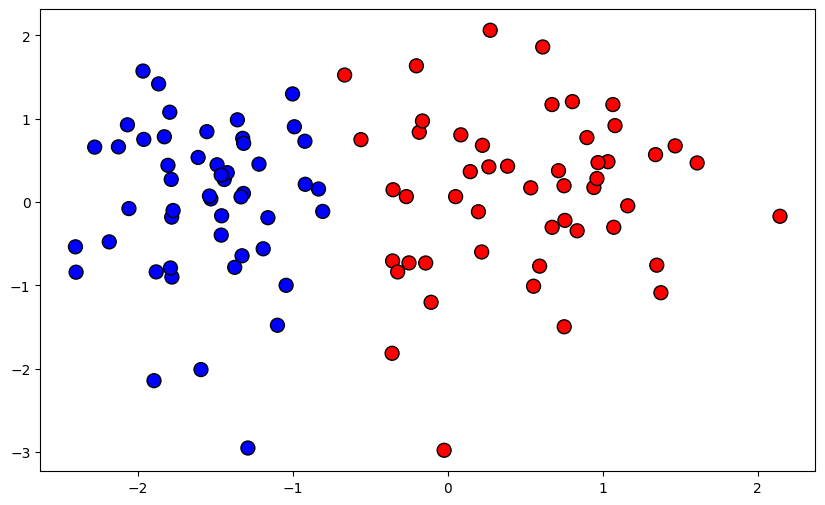

In [37]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='bwr',s=100,edgecolor='k')

In [38]:
def sigmoid(z):
    return 1/(1+np.exp(-z))


In [39]:
def coefficients(X,y):
    X=np.insert(X,0,1,axis=1)
    w=np.zeros(X.shape[1])
    for i in range(1000):
        j=np.random.randint(0,X.shape[0])
        z=np.dot(w,X[j])
        y_pred=sigmoid(z)
        w=w+(y[j]-y_pred)*X[j]
    return w[0],w[1:]

In [44]:
x_input=np.array([X[:,0].min(),X[:,0].max()])
intercept,coef=coefficients(X,y)


In [45]:
m=-coef[0]/coef[1]
c=-intercept/coef[1]
y_input=m*x_input+c

In [46]:
Z=np.dot(X,coef)+intercept
y_pred=sigmoid(Z)

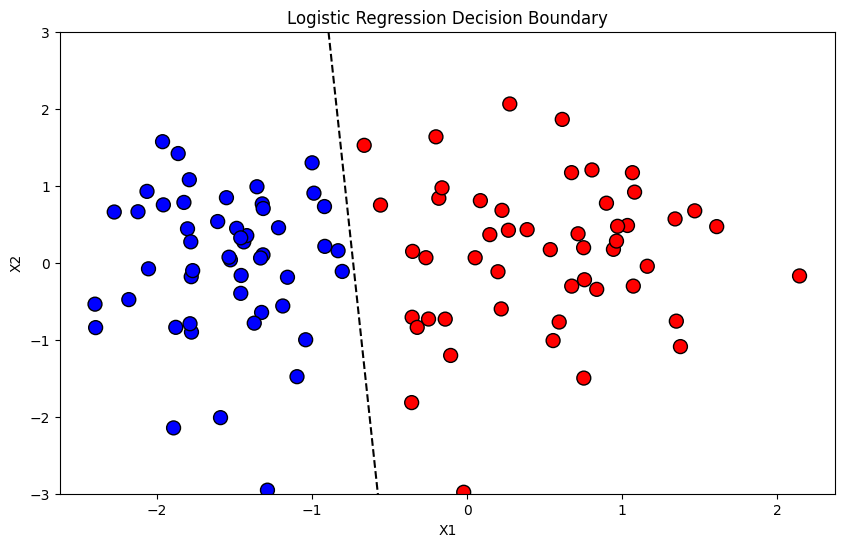

In [48]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='bwr',s=100,edgecolor='k')
plt.plot(x_input,y_input,'k--')
plt.xlabel('X1')    
plt.ylabel('X2')
plt.title('Logistic Regression Decision Boundary')
plt.ylim(-3,3)
plt.show()

# Logistic regression

In [49]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [50]:
model.fit(X,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [51]:
m=-(model.coef_[0][0])/(model.coef_[0][1])
c=-(model.intercept_)/(model.coef_[0][1])
y_input1=m*x_input+c

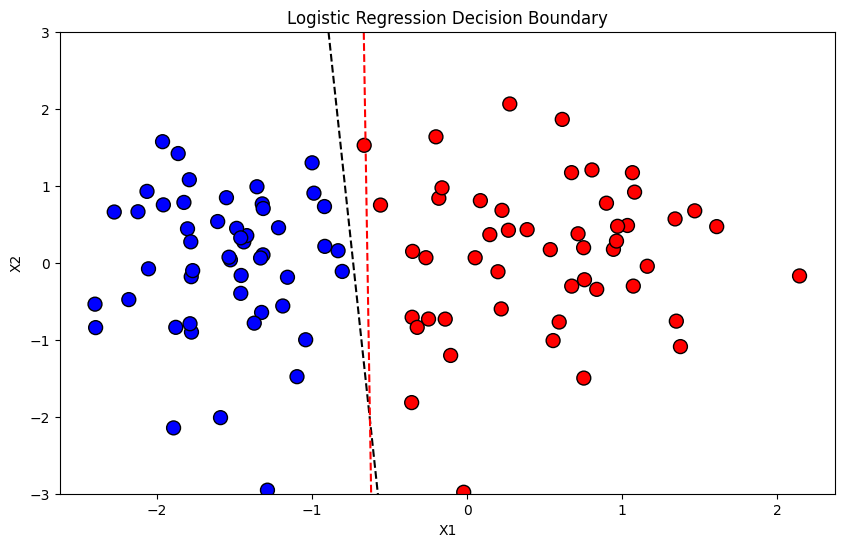

In [52]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='bwr',s=100,edgecolor='k')
plt.plot(x_input,y_input,'k--')
plt.plot(x_input,y_input1,'r--')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Logistic Regression Decision Boundary')
plt.ylim(-3,3)
plt.show()


# loss function